In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import linregress

plt.style.use("ggplot")

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/02_nav_history.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["amfi_code", "date"])
df["nav"] = df.groupby("amfi_code")["nav"].ffill()
df = df.drop_duplicates()
df = df[df["nav"] > 0]


In [22]:

plt.style.use("ggplot") 
nav = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [24]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.to_csv(
    "../outputs/daily_returns.csv",
    index=False
)

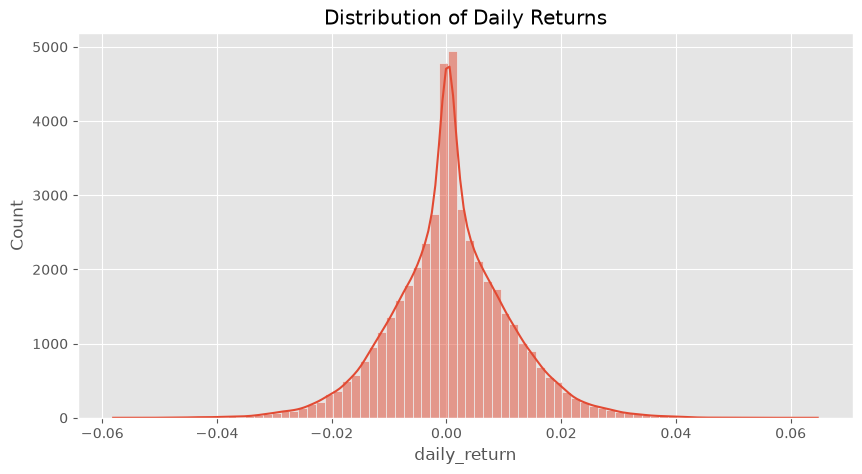

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"],
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.savefig("../charts/daily_return_distribution.png")

plt.show()

In [27]:
#CAGR
def cagr(start,end,years):

    return ((end/start)**(1/years))-1

records=[]
for code,df in nav.groupby("amfi_code"):
    df=df.sort_values("date")
    end=df.iloc[-1]["nav"]
    row={"amfi_code":code}
    for yrs in [1,3,5]:
        temp=df[df["date"]>=df["date"].max()-pd.DateOffset(years=yrs)]
        if len(temp)>0:
            start=temp.iloc[0]["nav"]
            row[f"CAGR_{yrs}Y"]=cagr(start,end,yrs)
    records.append(row)
cagr_df=pd.DataFrame(records)

cagr_df.to_csv(
    "../outputs/cagr_table.csv",
    index=False
)

In [28]:
# Sharpe Ratio 

RF=0.065
sharpe=[]
for code,df in nav.groupby("amfi_code"):
    r=df["daily_return"].dropna()
    sr=((r.mean()*252)-RF)/(r.std()*np.sqrt(252))
    sharpe.append([code,sr])
sharpe=pd.DataFrame(
    sharpe,
    columns=["amfi_code","Sharpe"]
)
sharpe.to_csv(
    "../outputs/sharpe_ratio.csv",
    index=False
)

sharpe=sharpe.sort_values(
    "Sharpe",
    ascending=False
)

In [29]:
# Sortino Ratio

sortino=[]
for code,df in nav.groupby("amfi_code"):
    r=df["daily_return"].dropna()
    downside=r[r<0]
    downside_std=downside.std()
    ratio=((r.mean()*252)-RF)/(downside_std*np.sqrt(252))
    sortino.append([code,ratio])

sortino=pd.DataFrame(
    sortino,
    columns=["amfi_code","Sortino"]
)

sortino.to_csv(
    "../outputs/sortino_ratio.csv",
    index=False
)

In [34]:
# Alpha & Beta

alpha=[]
benchmark["date"] = pd.to_datetime(benchmark["date"])
# Convert date
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort data
benchmark = benchmark.sort_values(["index_name", "date"])

# Calculate benchmark daily returns
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)
for code,df in nav.groupby("amfi_code"):
    merged=pd.merge(
        df,
        benchmark,
        on="date"
    )

    result=linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta=result.slope
    alpha_annual=result.intercept*252
    alpha.append([
        code,
        alpha_annual,
        beta
    ])

alpha=pd.DataFrame(
    alpha,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

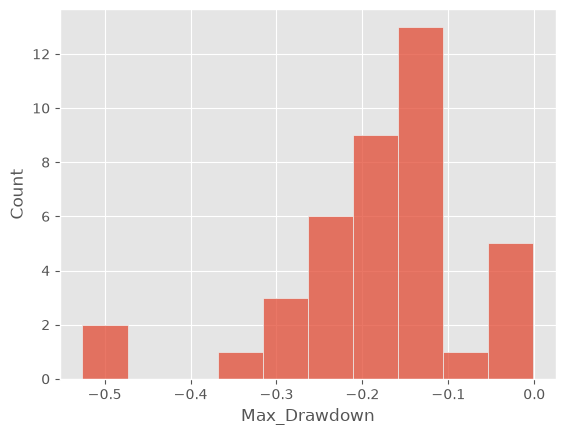

In [37]:
# Maximum Drawdown

drawdown=[]
for code,df in nav.groupby("amfi_code"):
    running=df["nav"].cummax()
    dd=df["nav"]/running-1
    drawdown.append([
        code,
        dd.min()
    ])

drawdown=pd.DataFrame(
    drawdown,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
)

drawdown.to_csv(
    "../outputs/max_drawdown.csv",
    index=False
)

sns.histplot(
    drawdown["Max_Drawdown"]
)

plt.savefig(
    "../charts/drawdown_chart.png"
)

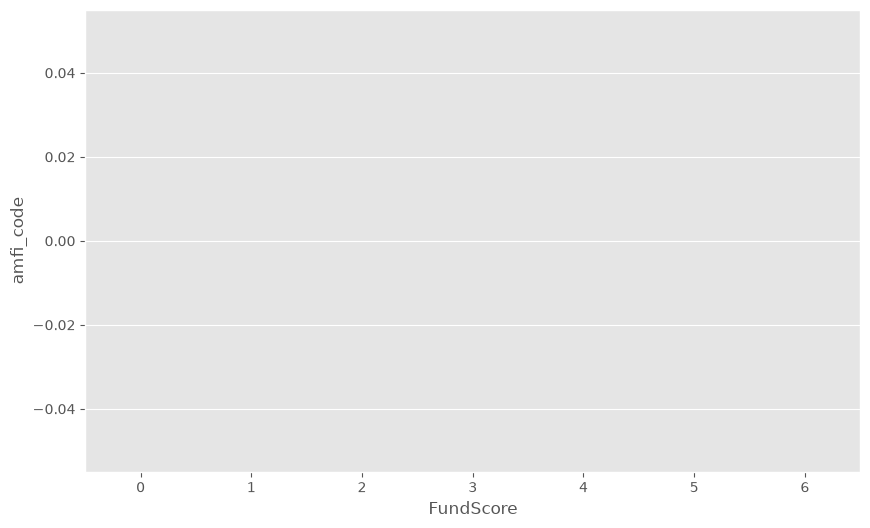

In [44]:
# Fund Scorecard

score=(
    cagr_df
    .merge(sharpe)
    .merge(alpha)
    .merge(drawdown)
    .merge(
        performance[
            ["amfi_code","expense_ratio_pct"]
        ]
    )
)

score["ReturnRank"]=score["CAGR_3Y"].rank()

score["SharpeRank"]=score["Sharpe"].rank()

score["AlphaRank"]=score["Alpha"].rank()

score["ExpenseRank"]=(
    score["expense_ratio_pct"]
    .rank(ascending=False)
)

score["DrawdownRank"]=(
    score["Max_Drawdown"]
    .rank(ascending=False)
)

score["FundScore"]=(
30*score["ReturnRank"]+
25*score["SharpeRank"]+
20*score["AlphaRank"]+
15*score["ExpenseRank"]+
10*score["DrawdownRank"]
)

score["FundScore"]=(
100*
score["FundScore"]/
score["FundScore"].max()
)

score.to_csv(
"../outputs/fund_scorecard.csv",
index=False
)

# Top 10 Scorecard
top=score.nlargest(10,"FundScore")

plt.figure(figsize=(10,6))

sns.barplot(
data=top,
x="FundScore",
y="amfi_code"
)

plt.savefig(
"../charts/scorecard_top10.png"
)

In [50]:
# Benchmark Comparison

fig=go.Figure()
for code in top.head(5)["amfi_code"]:
    df=nav[nav["amfi_code"]==code]
    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["nav"],
            name=str(code)
        )
    )

# NIFTY50
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"]

fig.add_trace(
    go.Scatter(
        x=nifty50["date"],
        y=nifty50["close_value"],
        name="NIFTY50"
    )
)

# NIFTY100
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"]

fig.add_trace(
    go.Scatter(
        x=nifty100["date"],
        y=nifty100["close_value"],
        name="NIFTY100"
    )
)

fig.show()
fig.write_image(
"../charts/benchmark_comparison.png"
)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
